In [1]:
import matplotlib.pyplot as plt
import pandas as pd

base_abc = pd.read_csv("Base_ABC_Flor-Colheita.csv")

In [2]:
#variaveis utilizadas

variaveis = [ 
    "UF",
    "NH.TMED < 10 [sum]",
    "ND.TMIN < 10 [sum]",
    "Altitude Média [classe]",
    "Semeadura [data]",
    "Colheita [data]",
    "Genótipos Propósito",
    "Tipo Safra",
    "Solo Textura",
    "Talhão",
    "Solo Grupo",
    "Amplitude Térmica [soma]",
    "Temperatura Ar Mínima [soma]",
    "Temperatura Ar Máxima [soma]",
    "Fotoperiodo [soma]",
    "Genótipos",
    "Precipitação [soma]",
    "Graus Dias [soma]",
    "Temperatura Ar [soma]",
    "Umidade Relativa Máxima [soma]",
    "Umidade Relativa Mínima [soma]",
    "Umidade Relativa [soma]",
    "Radiação Solar [soma]",
    "Evapotranspiração Potencial PM [soma]",
    "Evapotranspiração Potencial PM2 [soma]",
    "Temperatura Orvalho [soma]",
    "Temperatura Ar Noturna [ºC]",
    "Temperatura Molhamento Foliar [soma]",
    "Altitude Máxima [m]",
    "Altitude Média [m]",
    "Altitude Mínima [m]",
    "NH.UR > 90 [sum]",
    "Ciclo Semeadura-Colheita [dias]",
    "Fungicida Planejado [aplicações]",
    "Herbicida Planejado [aplicações]",
    "Inseticida Planejado [aplicações]",
    "ND.UR < 60 [sum]",
    "ND.UR > 80 [sum]",
    "ND.UR > 90 [sum]",
    "NH.UR < 60 [sum]",
    "Talhão Latitude [grau decimal]",
    "Talhão Longitude [grau decimal]",
    "Colheita [decendio]",
    "ND.RAD < 10 [sum]",
    "ND.PREC > 5 [sum]",
    "NH.RAD > 800 [sum]",
    "Semeadura [decendio]",
    "ND.PREC = 0.0 [sum]",
    "ND.TMAX > 30 [sum]",
    "ND.PREC > 0.2 [sum]",
    "ND.RAD > 20 [sum]",
    "NH.RAD > 1000 [sum]",
    "NH.RAD > 600 [sum]",
]

base_abc_X  = base_abc[variaveis].copy()
base_abc_Y = base_abc["Produtividade Realizada [kg/ha]"]

#transformando as datas
base_abc_X["Semeadura [data]"] = pd.to_datetime(base_abc_X["Semeadura [data]"], errors='coerce')
base_abc_X["Colheita [data]"] = pd.to_datetime(base_abc_X["Colheita [data]"], errors='coerce')

for col in ["Semeadura [data]", "Colheita [data]"]:
    base_abc_X[f"{col}_ano"] = base_abc_X[col].dt.year
    base_abc_X[f"{col}_mes"] = base_abc_X[col].dt.month
    base_abc_X[f"{col}_dia"] = base_abc_X[col].dt.day


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

variaveis_categoricas = [
    "UF",
    "Altitude Média [classe]",
    "Genótipos Propósito",
    "Tipo Safra",
    "Solo Textura",
    "Talhão",
    "Solo Grupo",
    "Genótipos"
]

variaveis_numericas = [
    "NH.TMED < 10 [sum]",
    "ND.TMIN < 10 [sum]",
    "Amplitude Térmica [soma]",
    "Temperatura Ar Mínima [soma]",
    "Temperatura Ar Máxima [soma]",
    "Fotoperiodo [soma]",
    "Precipitação [soma]",
    "Graus Dias [soma]",
    "Temperatura Ar [soma]",
    "Umidade Relativa Máxima [soma]",
    "Umidade Relativa Mínima [soma]",
    "Umidade Relativa [soma]",
    "Radiação Solar [soma]",
    "Evapotranspiração Potencial PM [soma]",
    "Evapotranspiração Potencial PM2 [soma]",
    "Temperatura Orvalho [soma]",
    "Temperatura Ar Noturna [ºC]",
    "Temperatura Molhamento Foliar [soma]",
    "NH.UR > 90 [sum]",
    "ND.UR < 60 [sum]",
    "ND.UR > 80 [sum]",
    "ND.UR > 90 [sum]",
    "NH.UR < 60 [sum]",
    "Talhão Latitude [grau decimal]",
    "Talhão Longitude [grau decimal]",
    "ND.RAD < 10 [sum]",
    "ND.PREC > 5 [sum]",
    "NH.RAD > 800 [sum]",
    "ND.PREC = 0.0 [sum]",
    "ND.TMAX > 30 [sum]",
    "ND.PREC > 0.2 [sum]",
    "ND.RAD > 20 [sum]",
    "NH.RAD > 1000 [sum]",
    "NH.RAD > 600 [sum]",
    "Semeadura [data]_ano",
    "Semeadura [data]_mes",
    "Semeadura [data]_dia",
    "Colheita [data]_ano",
    "Colheita [data]_mes",
    "Colheita [data]_dia",
    "Colheita [decendio]",
    "Semeadura [decendio]",
    "Inseticida Planejado [aplicações]",
    "Fungicida Planejado [aplicações]",
    "Herbicida Planejado [aplicações]",
    "Altitude Máxima [m]",
    "Altitude Média [m]",
    "Altitude Mínima [m]",
    "Ciclo Semeadura-Colheita [dias]",
]

#transforma valores que estavam sendo interpretados como str em valores numericos
for col in variaveis_numericas:
    if base_abc_X[col].dtype == "object":
        base_abc_X[col] = (
            base_abc_X[col].str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
            .astype(float)
        )

pipeline_numericas = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))  # preenche valores vazios com a média
])

pipeline_categoricas = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # preenche valores vazios com o valor mais comum
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  
])

preprocessador = ColumnTransformer(transformers=[
    ('num', pipeline_numericas, variaveis_numericas),
    ('cat', pipeline_categoricas, variaveis_categoricas)
])

In [4]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

mlp = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('scaler', StandardScaler(with_mean=False)),
    ('regressor', MLPRegressor())
])

knn = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('regressor', KNeighborsRegressor(n_neighbors = 3))
])

decision_tree = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('scaler', StandardScaler(with_mean=False)),
    ('regressor', DecisionTreeRegressor())
])

random_forest = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('scaler', StandardScaler(with_mean=False)),
    ('regressor', RandomForestRegressor())
])

In [5]:
mlp.fit(base_abc_X, base_abc_Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessamento', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [6]:
knn.fit(base_abc_X, base_abc_Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessamento', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [7]:
decision_tree.fit(base_abc_X, base_abc_Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessamento', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [8]:
random_forest.fit(base_abc_X, base_abc_Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessamento', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [9]:
decision_tree_importance = decision_tree.named_steps['regressor'].feature_importances_ #dessa forma pois é um pipeline

In [10]:
import numpy as np

# Pegar nomes das features após preprocessador
dt_onehot = decision_tree.named_steps['preprocessamento'].named_transformers_['cat'].named_steps['onehot']
dt_categorical_expanded_names = dt_onehot.get_feature_names_out(variaveis_categoricas)

dt_feature_names = np.concatenate([variaveis_numericas, dt_categorical_expanded_names])

dt_df_importances = pd.DataFrame({
    'feature_expanded': dt_feature_names,
    'importance': decision_tree_importance
})

# Pega o nome da variável antes do _ e agrupa
# Ex: Solo Grupo_A -> Solo Grupo
dt_df_importances['feature_original'] = dt_df_importances['feature_expanded'].apply(
    lambda x: x.split('_')[0] if x.split('_')[0] in variaveis_categoricas else x
)

dt_df_grouped = dt_df_importances.groupby('feature_original')['importance'].sum()
dt_df_grouped = dt_df_grouped.sort_values(ascending=False)

print(dt_df_grouped)

feature_original
Talhão Latitude [grau decimal]            0.215344
Talhão Longitude [grau decimal]           0.050990
Genótipos                                 0.047279
Talhão                                    0.046142
Altitude Mínima [m]                       0.034497
ND.TMAX > 30 [sum]                        0.030999
Precipitação [soma]                       0.030559
Fungicida Planejado [aplicações]          0.026550
NH.UR > 90 [sum]                          0.025283
Colheita [data]_dia                       0.024978
NH.RAD > 800 [sum]                        0.023514
Fotoperiodo [soma]                        0.022461
ND.PREC = 0.0 [sum]                       0.021244
Temperatura Ar Mínima [soma]              0.021068
Amplitude Térmica [soma]                  0.020248
ND.PREC > 0.2 [sum]                       0.020245
NH.UR < 60 [sum]                          0.019150
ND.RAD < 10 [sum]                         0.018549
Herbicida Planejado [aplicações]          0.017457
ND.RAD > 20 [s

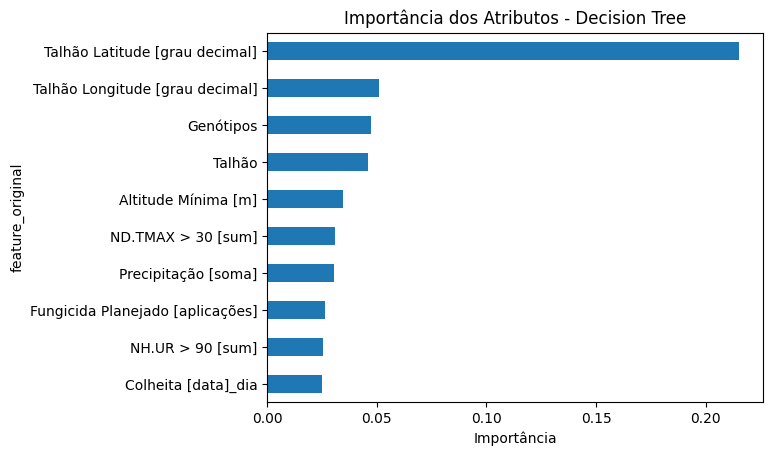

In [11]:
dt_df_grouped.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Importância dos Atributos - Decision Tree")
plt.xlabel("Importância")
plt.show()

In [12]:
random_forest_importance = random_forest.named_steps['regressor'].feature_importances_

In [13]:
rf_onehot = random_forest.named_steps['preprocessamento'].named_transformers_['cat'].named_steps['onehot']
rf_categorical_expanded_names = rf_onehot.get_feature_names_out(variaveis_categoricas)

rf_feature_names = np.concatenate([variaveis_numericas, rf_categorical_expanded_names])

rf_df_importances = pd.DataFrame({
    'feature_expanded': rf_feature_names,
    'importance': random_forest_importance
})

rf_df_importances['feature_original'] = rf_df_importances['feature_expanded'].apply(
    lambda x: x.split('_')[0] if x.split('_')[0] in variaveis_categoricas else x
)

rf_df_grouped = rf_df_importances.groupby('feature_original')['importance'].sum()
rf_df_grouped = rf_df_grouped.sort_values(ascending=False)

print(rf_df_grouped)

feature_original
Talhão Latitude [grau decimal]            0.202235
Talhão Longitude [grau decimal]           0.072841
Talhão                                    0.065961
Genótipos                                 0.059787
Altitude Mínima [m]                       0.035981
Precipitação [soma]                       0.026412
Colheita [data]_dia                       0.021928
Altitude Média [m]                        0.020581
Altitude Máxima [m]                       0.020120
Herbicida Planejado [aplicações]          0.019803
Semeadura [data]_dia                      0.019561
Fungicida Planejado [aplicações]          0.018725
ND.TMAX > 30 [sum]                        0.018518
NH.UR < 60 [sum]                          0.018181
NH.UR > 90 [sum]                          0.016960
Amplitude Térmica [soma]                  0.016713
NH.RAD > 1000 [sum]                       0.016363
ND.RAD < 10 [sum]                         0.016252
Inseticida Planejado [aplicações]         0.016081
ND.PREC = 0.0 

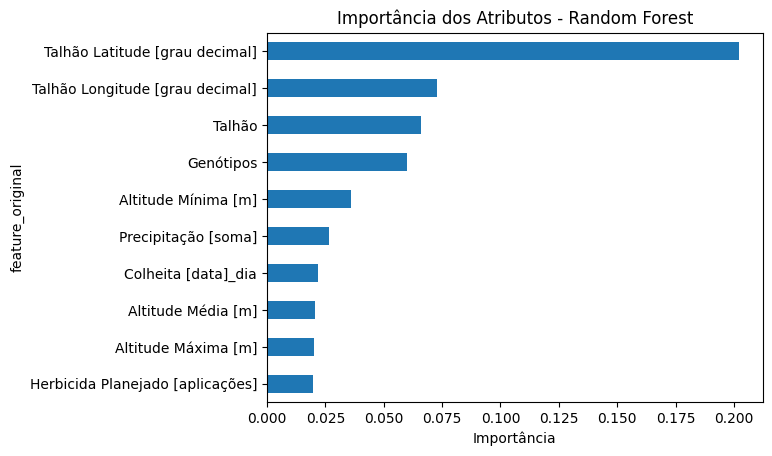

In [14]:
rf_df_grouped.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Importância dos Atributos - Random Forest")
plt.xlabel("Importância")
plt.show()

In [15]:
from sklearn.inspection import permutation_importance

mlp_importance = permutation_importance(mlp, base_abc_X, base_abc_Y, scoring="neg_mean_squared_error")

In [16]:
knn_importance = permutation_importance(knn, base_abc_X, base_abc_Y, scoring="neg_mean_squared_error")

In [17]:
print(mlp_importance.importances_mean)

[ 6.88660287e-03  4.55546155e-03  2.55962406e-03  2.33053094e-02
  0.00000000e+00  0.00000000e+00  2.42885317e-03  0.00000000e+00
  6.33396476e-03  1.04392362e+00  2.43315048e-02  1.00118408e-03
 -9.17437861e-06  8.47166816e-05 -3.26279555e-06  1.27204441e-01
 -6.48339498e-07 -5.99903390e-06  5.22618886e-04  2.85341546e-04
  6.05840365e-05  6.94487921e-04  8.41615868e-05  1.10867090e-03
  1.90181647e-03 -9.19173611e-06  9.17082350e-04  6.04415194e-04
  3.10669590e-04  1.05758926e-04  2.12578197e-03  3.09354168e-05
  3.29235376e-05  1.30626029e-03  2.96879214e-03  1.70347558e-04
  4.02641174e-03  9.28036840e-04  2.58011686e-03  8.86612344e-04
  1.66840506e-04  7.14748793e-04  2.84371439e-03  6.26962802e-04
  2.84369439e-04 -2.21516977e-06  2.76872703e-03  4.14505669e-05
  6.11905247e-06  8.43353245e-04  5.33423920e-04  1.64191232e-03
  5.87461522e-04  0.00000000e+00  1.69999589e-03  1.52669397e-04
  0.00000000e+00  1.78267392e-04  3.71729571e-04]


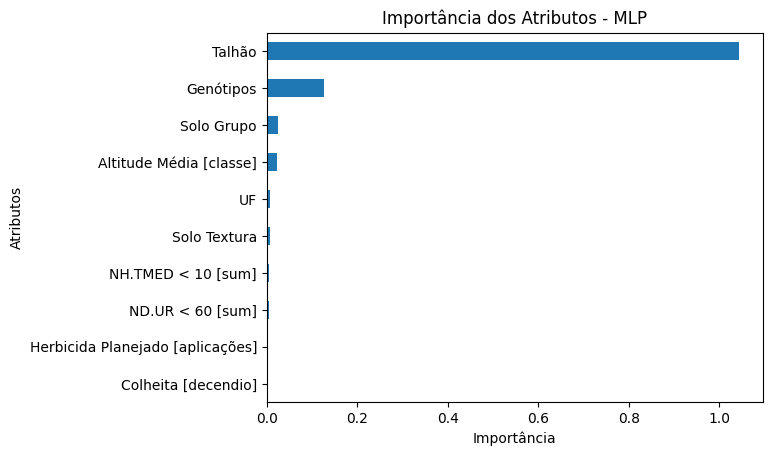

In [18]:
mlp_df_importances = pd.DataFrame({
    "feature": base_abc_X.columns,
    "importance": mlp_importance.importances_mean
})

mlp_top_10 = (
    mlp_df_importances
    .sort_values(by="importance", ascending=False)
    .head(10)
)

mlp_top_10.plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False
)

plt.gca().invert_yaxis()
plt.title("Importância dos Atributos - MLP")
plt.xlabel("Importância")
plt.ylabel("Atributos")
plt.show()

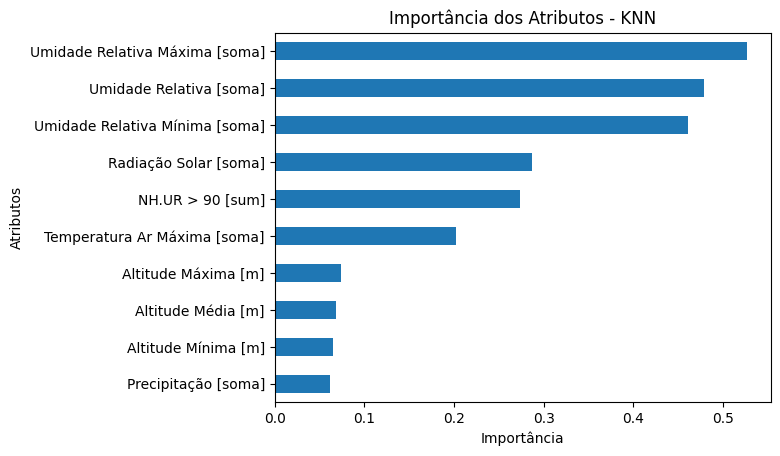

In [19]:
knn_df_importances = pd.DataFrame({
    "feature": base_abc_X.columns,
    "importance": knn_importance.importances_mean
})

knn_top_10 = (
    knn_df_importances
    .sort_values(by="importance", ascending=False)
    .head(10)
)

knn_top_10.plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False
)

plt.gca().invert_yaxis()
plt.title("Importância dos Atributos - KNN")
plt.xlabel("Importância")
plt.ylabel("Atributos")
plt.show()